In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

print(os.getcwd())

df = pd.read_csv("/Users/huss/data-processing/week5/amz_uk_price_prediction_dataset.csv")

/Users/huss/data-processing/week5/Labs/lab-eda-bivariate


In [2]:
#Part 1: Understanding Product Categories
#
#Business Question: What are the most popular product categories on Amazon UK, 
#and how do they compare in terms of listing frequency?
#
#Frequency Tables:
#
#Generate a frequency table for the product category.
#Which are the top 5 most listed product categories?
#Visualizations:
#
#Display the distribution of products across different categories using a bar chart. If you face problems understanding the chart, do it for a subset of top categories.
#For a subset of top categories, visualize their proportions using a pie chart. Does any category dominate the listings?



In [3]:
df.head()
#df.info()
#df.columns

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [4]:
freq = df["category"].value_counts()
print(freq)
#sports and outdoors, beauty and handmade clothing

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
                                           ...  
Alexa Built-In Devices                       107
Motorbike Chassis                            107
Plugs                                        107
Smart Home Security & Lighting               104
Smart Speakers                                54
Name: count, Length: 296, dtype: int64


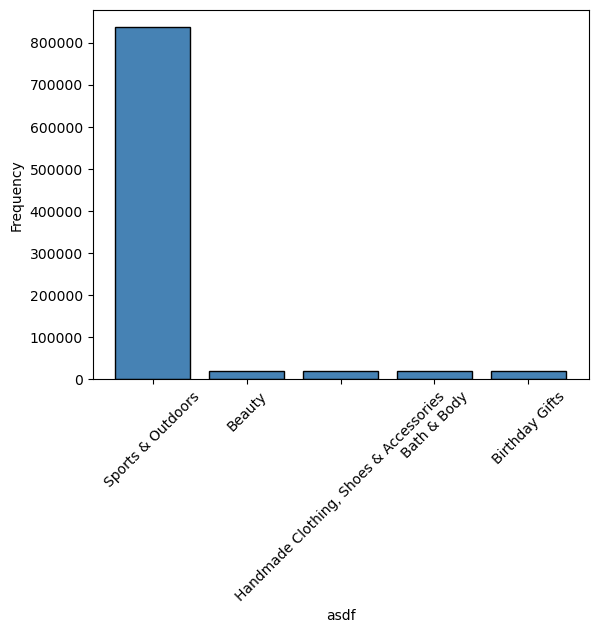

In [5]:
import matplotlib.pyplot as plt

freq = df["category"].value_counts()
top10 = freq.head(5)

plt.bar(top10.index, top10.values, color="steelblue", edgecolor="black")
plt.xlabel("asdf")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()


In [6]:
#Part 2: Delving into Product Pricing
#
#Business Question: How are products priced on Amazon UK, 
#and are there specific price points or ranges that are more common?
#
#Measures of Centrality:
#
#Calculate the mean, median, and mode for the price of products.
#What's the average price point of products listed? How does this compare with the most common price point (mode)?
#Measures of Dispersion:
#
#Determine the variance, standard deviation, range, and interquartile range for product price.
#How varied are the product prices? Are there any indicators of a significant spread in prices?
#Visualizations:
#
#Is there a specific price range where most products fall? Plot a histogram to visualize the distribution of product prices. If its hard to read these diagrams, think why this is, and explain how it could be solved..
#Are there products that are priced significantly higher than the rest? Use a box plot to showcase the spread and potential outliers in product pricing.

<Axes: xlabel='price', ylabel='Count'>

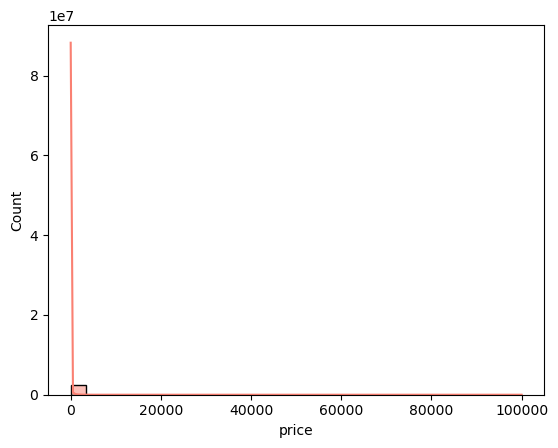

In [7]:
sns.histplot(df['price'], kde=True, bins=30, color="salmon")

<Axes: ylabel='price'>

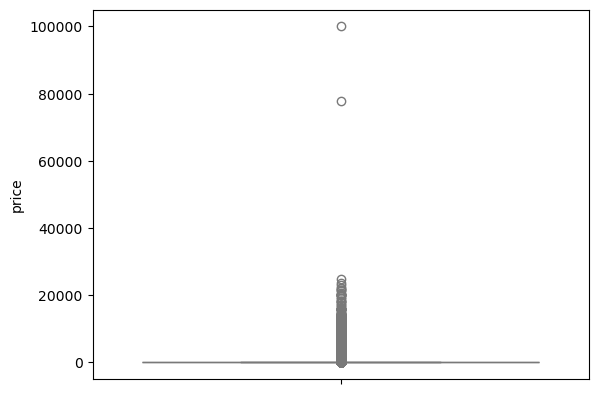

In [8]:
sns.boxplot(data = df['price'], color="lightblue")

In [9]:
#Part 3: Unpacking Product Ratings
#
#Business Question: How do customers rate products on Amazon UK, 
#and are there any patterns or tendencies in the ratings?
#
#Measures of Centrality:
#
#Calculate the mean, median, and mode for the rating of products.
#How do customers generally rate products? Is there a common trend?
#Measures of Dispersion:
#
#Determine the variance, standard deviation, and interquartile range for product rating.
#Are the ratings consistent, or is there a wide variation in customer feedback?
#Shape of the Distribution:
#
#Calculate the skewness and kurtosis for the rating column.
#Are the ratings normally distributed, or do they lean towards higher or lower values?
#Visualizations:
#
#Plot a histogram to visualize the distribution of product ratings. Is there a specific rating that is more common?

<Axes: xlabel='stars', ylabel='Count'>

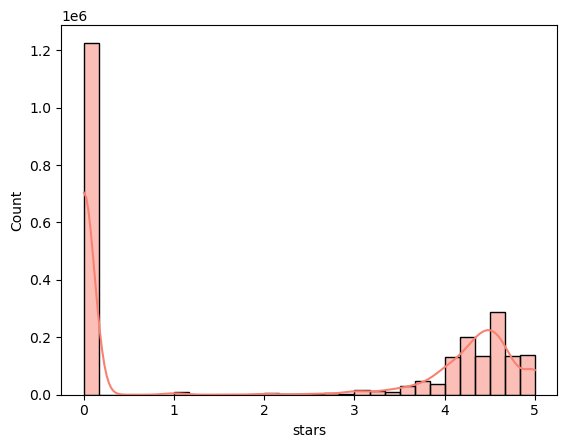

In [10]:
sns.histplot(df['stars'], kde=True, bins=30, color="salmon")

<Axes: ylabel='stars'>

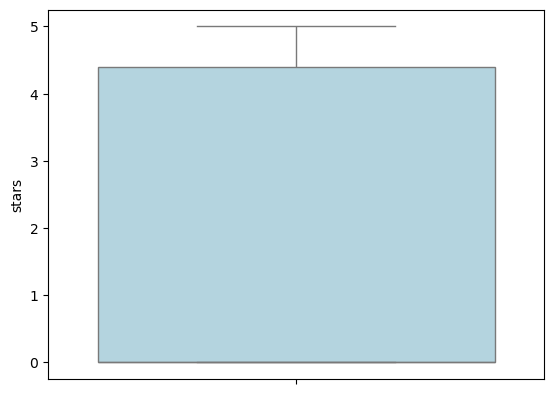

In [11]:
sns.boxplot(data = df['stars'], color="lightblue")

In [20]:
df['SalePrice_quantile'] = pd.qcut(df['SalePrice'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

df.SalePrice_category.value_counts()

In [ ]:
# Discretizing 'SalePrice' into 4 categories
bins = [0, 100000, 200000, 300000, df['SalePrice'].max()]
labels = ['Low', 'Medium', 'High', 'Very High']
df['SalePrice_category'] = pd.cut(df['price'], bins=bins, labels=labels, include_lowest=True)

In [ ]:
# 1. Crosstab: category vs isBestSeller
ct = pd.crosstab(df["category"], df["isBestSeller"])

# Proportion of best‑sellers per category (i.e., best‑seller rate)
ct_pct = pd.crosstab(df["category"], df["isBestSeller"], normalize="index") * 100

# Sort categories by best‑seller proportion (descending)
best_seller_prop = ct_pct[True].sort_values(ascending=False)
print("Top 10 categories by best‑seller proportion:")
print(best_seller_prop.head(10))






In [ ]:
# 4. Stacked bar chart: category vs best‑seller status

# Aggregate top N categories for cleaner plot
top_cats = df["category"].value_counts().head(20).index
ct_plot = pd.crosstab(
    df[df["category"].isin(top_cats)]["category"],
    df[df["category"].isin(top_cats)]["isBestSeller"]
)

ct_plot.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("Stacked Bar Chart: Best‑Seller Status by Category (Top 20)")
plt.xlabel("Product Category")
plt.ylabel("Count")
plt.legend(title="isBestSeller", labels=["Not Best‑Seller", "Best‑Seller"])
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [17]:

median_price_by_cat = df_no_outliers.groupby("category")["price"].median().sort_values(ascending=False)
print("\nMedian price per category (all categories, descending):")
print(median_price_by_cat.head())




Median price per category (all categories, descending):
category
Desktop PCs       74.00
Boxing Shoes      69.79
Tablets           69.00
Graphics Cards    68.54
Motherboards      67.92
Name: price, dtype: float64


In [15]:

# ======================================
# Part 2: Prices and Ratings by Category
# ======================================

# 1. Remove outliers in price using IQR

Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_no_outliers = df[
    (df["price"] >= lower_bound) &
    (df["price"] <= upper_bound)
].copy()

print(f"\nNumber of rows before outlier removal: {len(df)}")
print(f"Number of rows after outlier removal: {len(df_no_outliers)}")



Number of rows before outlier removal: 2443651
Number of rows after outlier removal: 2115963


In [21]:
# 2. Chi‑square test of independence

# Drop rows with missing isBestSeller if any
df_clean = df.dropna(subset=["isBestSeller", "category"])

ct_chi2 = pd.crosstab(df_clean["category"], df_clean["isBestSeller"])
chi2, p, dof, expected = stats.chi2_contingency(ct_chi2)

print(f"\nChi‑square test (category vs isBestSeller):")
print(f"Chi‑square statistic: {chi2:.2f}")
print(f"p‑value: {p:.4f}")
print("p < 0.05 suggests category and best‑seller status are NOT independent.")




NameError: name 'stats' is not defined

In [22]:

# 3. Cramér’s V (strength of association)

n = ct_chi2.sum().sum()  # total sample size
r, c = ct_chi2.shape
cramers_v = np.sqrt(chi2 / (n * min(r - 1, c - 1)))

print(f"\nCramér’s V: {cramers_v:.4f}")
print("Interpretation: 0 = no association, 1 = perfect association.")

NameError: name 'chi2' is not defined

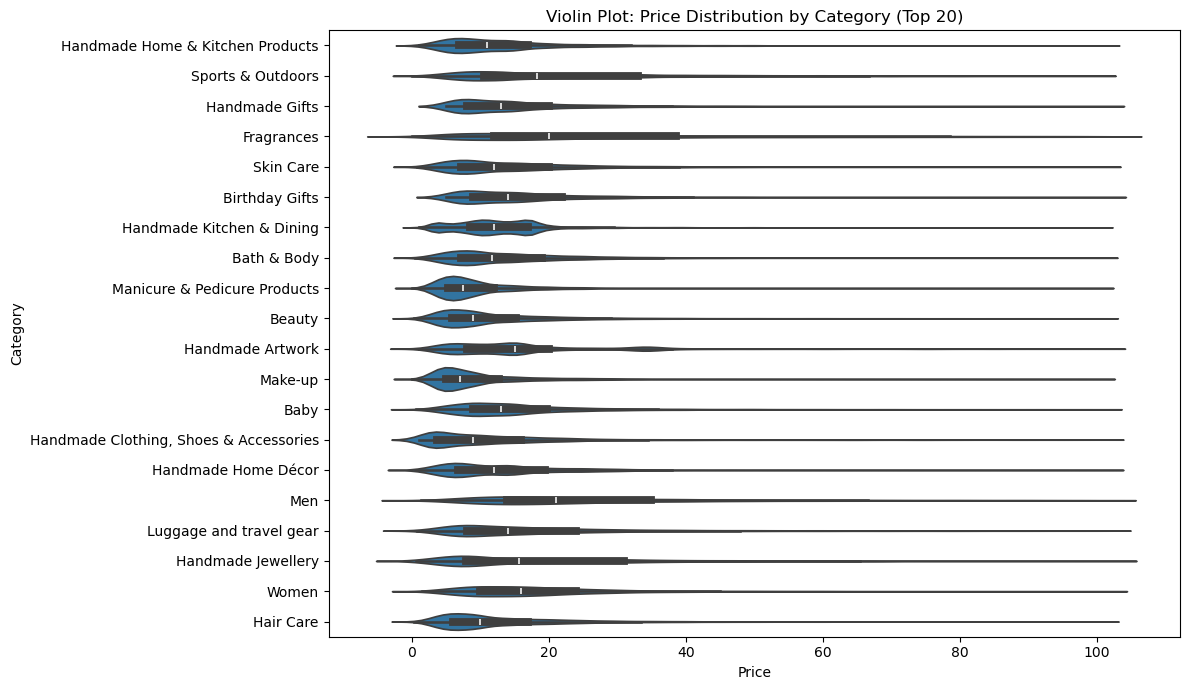


Median price per category (all categories, descending):
category
Desktop PCs       74.00
Boxing Shoes      69.79
Tablets           69.00
Graphics Cards    68.54
Motherboards      67.92
Name: price, dtype: float64


In [16]:

top20_cats = df_no_outliers["category"].value_counts().head(20).index
df_top20 = df_no_outliers[df_no_outliers["category"].isin(top20_cats)]

plt.figure(figsize=(12, 7))
sns.violinplot(
    data=df_top20,
    x="price",
    y="category",
    orient="h"
)
plt.title("Violin Plot: Price Distribution by Category (Top 20)")
plt.xlabel("Price")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

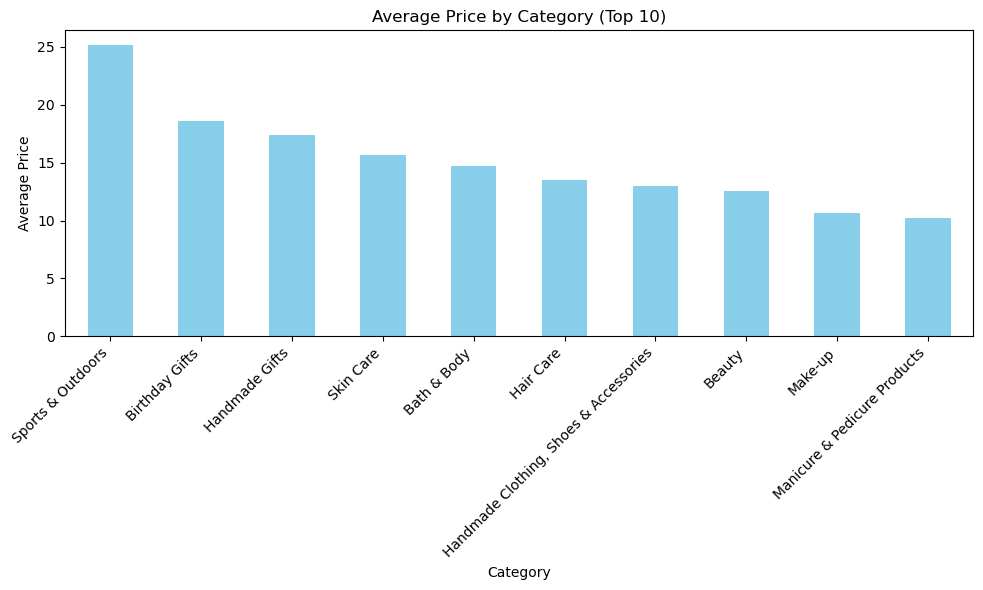


Average price per category (all categories, descending):
category
Motherboards      68.772432
Boxing Shoes      67.417803
Desktop PCs       66.915562
Tablets           66.552971
Graphics Cards    65.103509
Name: price, dtype: float64


In [18]:


top10_cats = df_no_outliers["category"].value_counts().head(10).index
top10_df = df_no_outliers[df_no_outliers["category"].isin(top10_cats)]

avg_price = top10_df.groupby("category")["price"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
avg_price.plot(kind="bar", color="skyblue")
plt.title("Average Price by Category (Top 10)")
plt.xlabel("Category")
plt.ylabel("Average Price")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\nAverage price per category (all categories, descending):")
print(df_no_outliers.groupby("category")["price"].mean().sort_values(ascending=False).head())

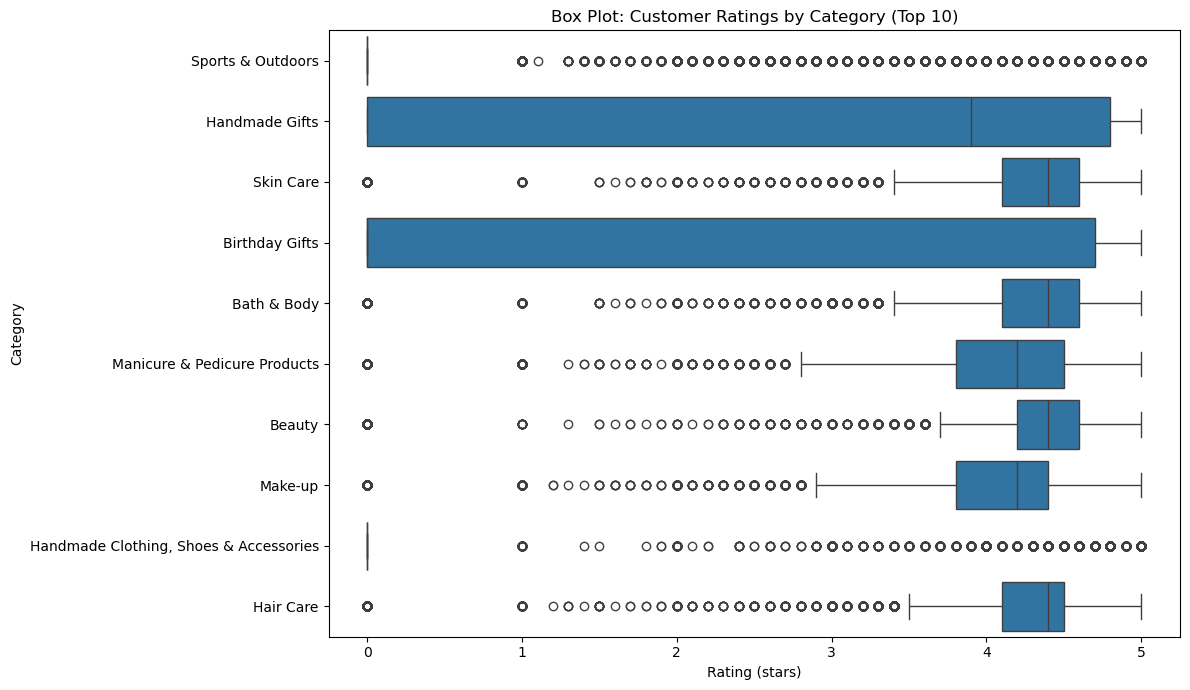


Median rating per category (all categories, descending):
category
Computer Memory                 4.7
Building & Construction Toys    4.6
Office Paper Products           4.6
Luxury Food & Drink             4.6
Kids' Play Figures              4.6
Name: stars, dtype: float64


In [19]:


top10_cats_stars = df_no_outliers["category"].value_counts().head(10).index
df_top10_stars = df_no_outliers[df_no_outliers["category"].isin(top10_cats_stars)]

plt.figure(figsize=(12, 7))
sns.boxplot(
    data=df_top10_stars,
    x="stars",
    y="category"
)
plt.title("Box Plot: Customer Ratings by Category (Top 10)")
plt.xlabel("Rating (stars)")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

# Median rating across all categories (unfiltered by top 10)
median_stars_by_cat = df_no_outliers.groupby("category")["stars"].median().sort_values(ascending=False)
print("\nMedian rating per category (all categories, descending):")
print(median_stars_by_cat.head())